# 04. Statistical Analysis & t-SNE (3-Class)

## Overview
This notebook performs the **Exploratory Data Analysis (EDA)** on the extracted features. Before feeding raw signals into a neural network, it's often useful to see if simple statistical features can discriminate between classes.

### Features Extracted
For each signal (time series), we extract 4 statistical moments:
1.  **Mean:** Average amplitude (reflects DC offset/baseline drift).
2.  **Standard Deviation (Std):** Measure of signal energy/power.
3.  **Kurtosis:** Measure of "tailedness" or outliers (spikes).
4.  **Skewness:** Measure of asymmetry.


In [15]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Add src to path
sys.path.append(os.path.abspath('..'))

from src.data_processing.loader import load_bonn_data

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

## 1. Load Data & Extract Features

In [16]:
data_path = os.path.join('..', 'data', 'raw')
X, y = load_bonn_data(data_path)

print(f"Data Shape: {X.shape}")

features = []
for signal in X:
    f_mean = np.mean(signal)
    f_std = np.std(signal)
    f_kurt = kurtosis(signal)
    f_skew = skew(signal)
    features.append([f_mean, f_std, f_kurt, f_skew])

X_features = np.array(features)
feature_names = ['Mean', 'Std Dev', 'Kurtosis', 'Skewness']

df_features = pd.DataFrame(X_features, columns=feature_names)
label_map = {0: 'Healthy', 1: 'Inter-ictal', 2: 'Seizure'}
df_features['Label'] = [label_map[label] for label in y]

df_features.head()

Loading 100 files from Z mapped to Class 0...
Loading 100 files from O mapped to Class 0...
Loading 100 files from N mapped to Class 0...
Loading 100 files from F mapped to Class 0...
Loading 100 files from S mapped to Class 1...
Data Shape: (500, 4097)


,Mean,Std Dev,Kurtosis,Skewness,Label
0,-75.103734,23.114444,-0.001472,0.076754,Healthy
1,-3.992433,47.072316,0.185732,0.063678,Healthy
2,-27.369539,43.700314,0.307253,0.202650,Healthy
3,-13.600195,38.416544,0.283853,-0.120190,Healthy
4,-17.999268,44.910958,0.397312,0.142753,Healthy


## 2. Statistical Analysis (Boxplots)
Boxplots are excellent for identifying separability between classes based on single features.

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_27168/4269519826.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=feature, data=df_features, ax=axes[i], palette='viridis')
/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_27168/4269519826.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=feature, data=df_features, ax=axes[i], palette='viridis')
/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_27168/4269519826.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=feature,

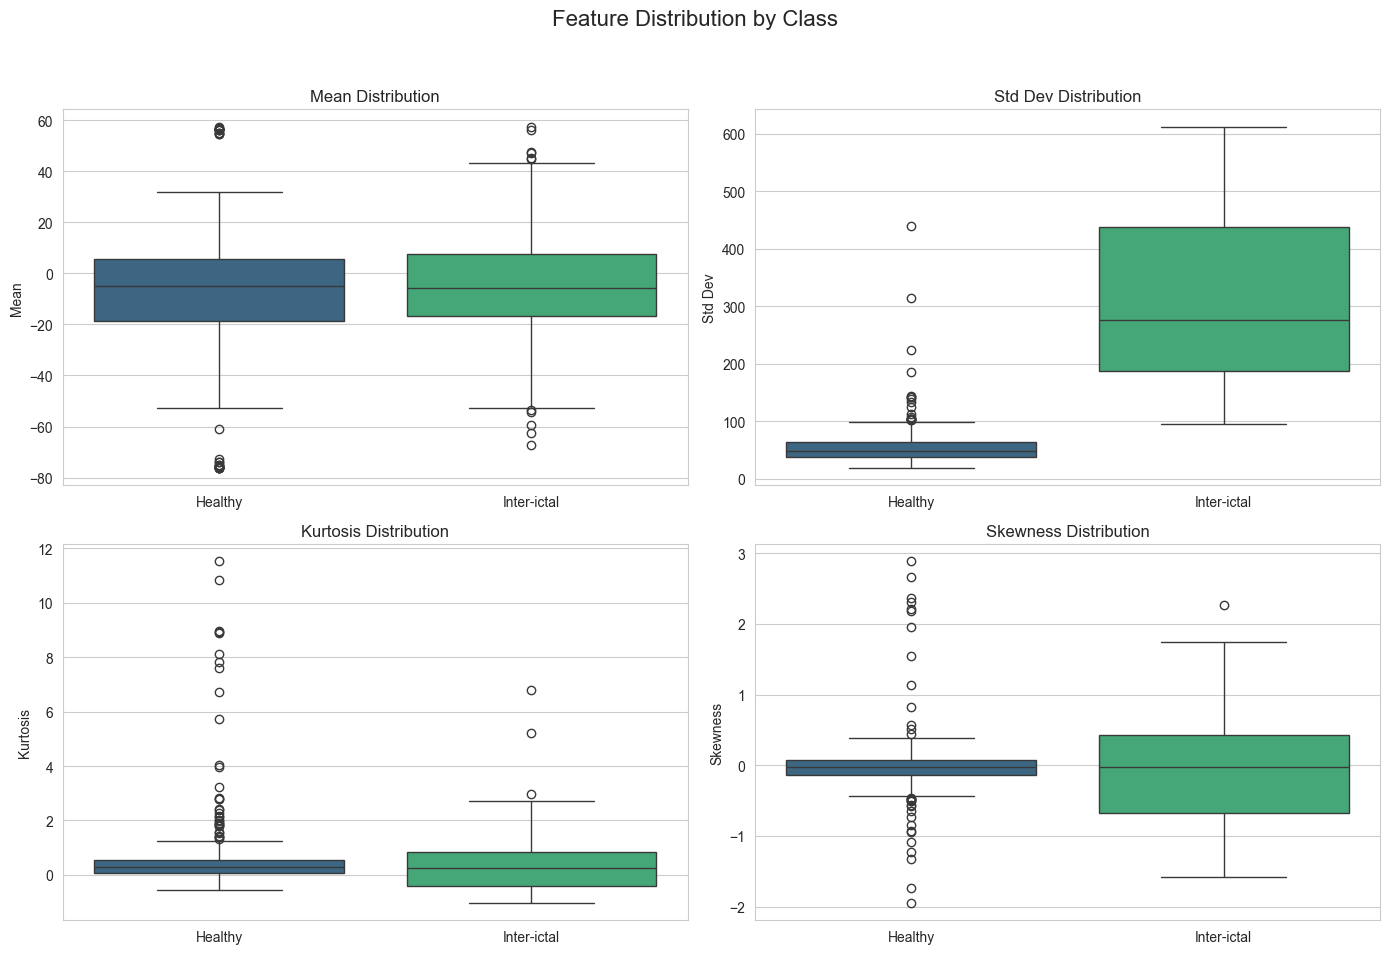

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Distribution by Class", fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    sns.boxplot(x='Label', y=feature, data=df_features, ax=axes[i], palette='viridis')
    axes[i].set_title(f"{feature} Distribution")
    axes[i].set_xlabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

> **Interpretation:**
> *   **Std Dev:** Seizure signals (Class 2) show a drastically higher median and wider range variability compared to Healthy/Inter-ictal. This suggests signal energy is a key discriminator.
> *   **Kurtosis/Skewness:** Seizure signals also tend to have more varying kurtosis, indicating "spikier" behavior.

---

## 3. Dimensionality Reduction (t-SNE)
Since looking at 4 features at once is impossible, we project them into 2D using t-SNE. This unsupervised technique clusters similar data points together.

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_27168/1575068288.py:19: RuntimeWarning: Mean of empty slice
  plt.text(X_embedded[y==2, 0].mean(), X_embedded[y==2, 1].mean(), "Seizure Cluster",
/Users/filipapopova/source/repos/2526-dzi-ai-FHPopova21/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


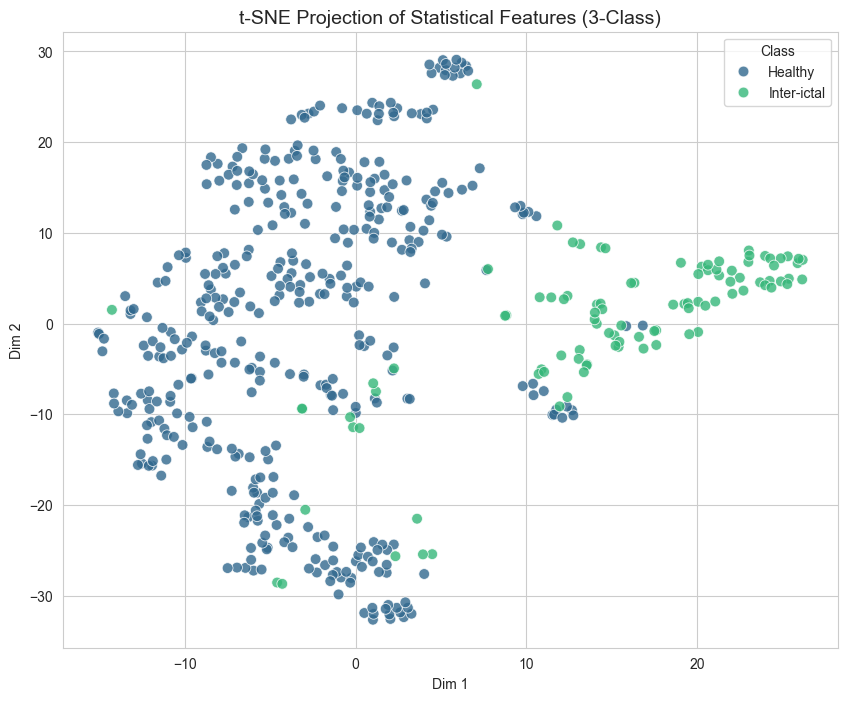

In [18]:
# Normalize Features (Critical for t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_embedded = tsne.fit_transform(X_scaled)

# Create DataFrame for Plotting
df_tsne = pd.DataFrame(X_embedded, columns=['Dim 1', 'Dim 2'])
df_tsne['Label'] = df_features['Label']

# Plot Result
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_tsne, x='Dim 1', y='Dim 2', hue='Label', palette='viridis', alpha=0.8, s=60)
plt.title("t-SNE Projection of Statistical Features (3-Class)", fontsize=14)

# Annotate Clusters
plt.text(X_embedded[y==2, 0].mean(), X_embedded[y==2, 1].mean(), "Seizure Cluster", 
         fontsize=12, fontweight='bold', color='red', ha='center', bbox=dict(facecolor='white', alpha=0.7))

plt.legend(title='Class')
plt.show()

> **Conclusion:** The t-SNE plot clearly shows a distinct cluster for **Seizure** signals (yellow/green), well-separated from Healthy and Inter-ictal. This suggests that simple statistical features are already quite powerful for detecting ictal states.